# Debug run: qaccess_t_dynamic only (Fig.7-style)

Single-run analysis for `session_debug_qaccess_t_dynamic` — **qaccess_t_dynamic** with logs + pcaps (successful debug, no early `output stalled`).

**Topology:** `fig7` + `bw_profile.fig7_200s.env` on `h2-eth1` (20 → 30 → 10 Mbps).

**Primary metric:** total QUIC wire throughput (Path A + Path B downlink).

**§8** compares **fig7_baseline** from `session_fig7_dynamic_20260601_101430` with this debug **qaccess_t_dynamic** run (QUIC wire + window table).

Optional **§9**: failed `fig7_qaccess_t_dynamic` leg from the same session (early stall; pcaps only if synced).


## 1. Setup

In [1]:
import importlib.util
import re
import subprocess
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

_PACKAGES = ["pandas", "matplotlib"]
_missing = [p for p in _PACKAGES if importlib.util.find_spec(p) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

def find_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return cwd

REPO = find_repo()
print("REPO =", REPO)


REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


## 2. Paths

In [2]:
SESSION = REPO / "logs_exp" / "session_debug_qaccess_t_dynamic"
RUN_DIR = SESSION / "fig7_qaccess_t_dynamic_debug"
RUN_ID = "20260601_110641"

# Previous full eval session: fig7_baseline (for comparison)
FIG7_SESSION = REPO / "logs_exp" / "session_fig7_dynamic_20260601_101430"
BASELINE_RUN = FIG7_SESSION / "fig7_baseline"

# Failed qaccess_t_dynamic leg from same session (early stall ~99s)
FAILED_RUN = FIG7_SESSION / "fig7_qaccess_t_dynamic"

OUT_DIR = SESSION / "compare_csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LOGS = RUN_DIR / "logs"
PCAPS = RUN_DIR / "pcaps"
OUTPUT_FLV = RUN_DIR / f"output_{RUN_ID}.flv"

PATH_A_DOWNLINK = "udp && ip.src == 10.0.1.2 && ip.dst == 10.0.1.1"
PATH_B_DOWNLINK = "udp && ip.src == 10.0.2.2 && ip.dst == 10.0.2.1"

SECOND_MAX = 220

WINDOWS = [
    ("0-50", 0, 50), ("50-60", 50, 60), ("50-100", 50, 100),
    ("100-110", 100, 110), ("100-150", 100, 150),
]

FIG_TOTAL = OUT_DIR / "debug_total_quic_throughput.png"
FIG_PATHS = OUT_DIR / "debug_per_path_quic_throughput.png"
FIG_PATHB_CAP = OUT_DIR / "debug_pathB_vs_capacity.png"
CSV_TS = OUT_DIR / "debug_quic_timeseries.csv"
CSV_WINDOWS = OUT_DIR / "debug_quic_window_summary.csv"

print("RUN_DIR:", RUN_DIR.resolve())
print("OUTPUT_FLV:", OUTPUT_FLV, "exists" if OUTPUT_FLV.is_file() else "MISSING")
for p in [LOGS / f"pull_{RUN_ID}.log", LOGS / f"push_{RUN_ID}.log", LOGS / f"server_{RUN_ID}.log", LOGS / f"tc_bw_{RUN_ID}.log"]:
    print(f"  {p.name}: {'ok' if p.is_file() else 'MISSING'}", f"({p.stat().st_size/1e6:.1f} MB)" if p.is_file() else "")


RUN_DIR: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic/fig7_qaccess_t_dynamic_debug
OUTPUT_FLV: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic/fig7_qaccess_t_dynamic_debug/output_20260601_110641.flv exists
  pull_20260601_110641.log: ok (275.5 MB)
  push_20260601_110641.log: ok (467.6 MB)
  server_20260601_110641.log: ok (705.0 MB)
  tc_bw_20260601_110641.log: ok (0.0 MB)


## 3. Log inspection (watchdog, tc, qaccess_t triggers)

In [3]:
def grep_log(path: Path, pattern: str, max_lines: int = 200) -> list[str]:
    if not path.is_file():
        return []
    out = []
    rx = re.compile(pattern)
    with path.open("r", errors="replace") as f:
        for line in f:
            if rx.search(line):
                out.append(line.rstrip())
                if len(out) >= max_lines:
                    break
    return out


def tail_log(path: Path, n: int = 40) -> list[str]:
    if not path.is_file():
        return []
    lines = path.read_text(errors="replace").splitlines()
    return lines[-n:]


pull_log = LOGS / f"pull_{RUN_ID}.log"
push_log = LOGS / f"push_{RUN_ID}.log"
tc_log = LOGS / f"tc_bw_{RUN_ID}.log"
combined_log = LOGS / f"combined_{RUN_ID}.log"

print("=== tc_bw (full file is small) ===")
if tc_log.is_file():
    print(tc_log.read_text(errors="replace"))

print("\n=== qaccess_t triggers (pull) ===")
triggers = grep_log(pull_log, r"trigger update|buffer_ready|throughput_drop")
for line in triggers:
    print(line)
print(f"count={len(triggers)}")

print("\n=== coefficient reloads (pull) ===")
reloads = grep_log(pull_log, r"reloaded coefficients", max_lines=50)
for line in reloads:
    print(line)
print(f"count={len(reloads)}")

print("\n=== watchdog / mp_topo (combined, if present) ===")
wd = grep_log(combined_log, r"\[watchdog\]|output stalled|push exited|timeout reached|input   =", max_lines=30)
if wd:
    for line in wd:
        print(line)
else:
    print("(no watchdog lines in combined — check VM console or re-run with SAVE_LOGS=1 and mp_topo stderr)")

print("\n=== pull log: first / last timestamp ===")
for label, p in [("pull", pull_log), ("push", push_log)]:
    if not p.is_file():
        continue
    lines = [ln for ln in p.read_text(errors="replace").splitlines() if ln[:4].isdigit() or ln.startswith("202")]
    if lines:
        print(f"  {label}: first={lines[0][:19]} last={lines[-1][:19]} lines={len(lines)}")

print("\n=== push log tail (last 15 lines) ===")
for line in tail_log(push_log, 15):
    print(line)


=== tc_bw (full file is small) ===
[2026-06-01T11:06:42+00:00] [tc_bw] profile=scripts/mininet/bw_profile.fig7_200s.env
[2026-06-01T11:06:42+00:00] [tc_bw] parsed IFACE=h2-eth1 step_count=3
[2026-06-01T11:06:42+00:00] [tc_bw] profile_step[0] at=0s bw=20mbit
[2026-06-01T11:06:42+00:00] [tc_bw] profile_step[1] at=50s bw=30mbit
[2026-06-01T11:06:42+00:00] [tc_bw] profile_step[2] at=100s bw=10mbit
[2026-06-01T11:06:42+00:00] [tc_bw] timeline_origin=tc_bw_steps.sh start (sleep/s steps are relative to this moment)
[2026-06-01T11:06:42+00:00] [tc_bw] step 1/3 at=0s bw=20mbit dev=h2-eth1
[2026-06-01T11:06:42+00:00] [tc_bw] tc_cmd: tc qdisc replace dev h2-eth1 root tbf rate 20mbit burst 64kbit latency 400ms
[2026-06-01T11:06:42+00:00] [tc_bw] qdisc_show: qdisc tbf 8009: root refcnt 5 rate 20Mbit burst 8Kb lat 400ms 
[2026-06-01T11:06:42+00:00] [tc_bw] qdisc_stats: qdisc tbf 8009: root refcnt 5 rate 20Mbit burst 8Kb lat 400ms 
[2026-06-01T11:06:42+00:00] [tc_bw] qdisc_stats:  Sent 0 bytes 0 pkt 

## 4. Output FLV vs pcap duration

In [4]:
def flv_size_mbps(path: Path, duration_s: float) -> float:
    if not path.is_file() or duration_s <= 0:
        return float("nan")
    return path.stat().st_size * 8 / duration_s / 1e6


def capinfos_duration(pcap: Path) -> float:
    r = subprocess.run(["capinfos", str(pcap)], capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if "Capture duration" in line:
            return float(line.split()[-2])
    return float("nan")

pcap_a = next(PCAPS.glob("pathA*.pcap"))
pcap_b = next(PCAPS.glob("pathB*.pcap"))
dur_a = capinfos_duration(pcap_a)
dur_b = capinfos_duration(pcap_b)
pcap_dur = min(dur_a, dur_b)
print(f"pcap duration: pathA={dur_a:.1f}s pathB={dur_b:.1f}s use={pcap_dur:.1f}s")
if OUTPUT_FLV.is_file():
    print(f"output FLV: {OUTPUT_FLV.stat().st_size/1e6:.2f} MB, est app bitrate={flv_size_mbps(OUTPUT_FLV, pcap_dur):.2f} Mbps")
else:
    print("output FLV: missing")


pcap duration: pathA=125.8s pathB=125.6s use=125.6s
output FLV: 151.98 MB, est app bitrate=9.68 Mbps


## 5. QUIC wire throughput from pcaps

In [5]:
import math


def read_bins(pcap: Path, filt: str) -> defaultdict:
    bins = defaultdict(int)
    cmd = [
        "tshark", "-r", str(pcap), "-Y", filt,
        "-T", "fields", "-E", "separator=\t",
        "-e", "frame.time_relative", "-e", "frame.len",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr[:500])
    for line in proc.stdout.splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        try:
            si = int(math.floor(float(parts[0])))
            bins[si] += int(parts[1])
        except ValueError:
            pass
    return bins


def to_df(bins_a, bins_b, last_s: int) -> pd.DataFrame:
    df = pd.DataFrame({
        "second": range(0, last_s + 1),
        "pathA_quic_mbps": [bins_a.get(s, 0) * 8 / 1e6 for s in range(0, last_s + 1)],
        "pathB_quic_mbps": [bins_b.get(s, 0) * 8 / 1e6 for s in range(0, last_s + 1)],
    })
    df["total_quic_mbps"] = df["pathA_quic_mbps"] + df["pathB_quic_mbps"]
    return df


print("Reading pcaps (QUIC wire downlink)...", flush=True)
ba = read_bins(pcap_a, PATH_A_DOWNLINK)
bb = read_bins(pcap_b, PATH_B_DOWNLINK)
last_s = int(min(SECOND_MAX, pcap_dur, max(ba.keys(), default=0), max(bb.keys(), default=0)))
df = to_df(ba, bb, last_s)
df.to_csv(CSV_TS, index=False)
print(f"Wrote {CSV_TS} rows={len(df)} last_s={last_s}")
df.head()


Reading pcaps (QUIC wire downlink)...
Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic/compare_csv/debug_quic_timeseries.csv rows=126 last_s=125


,second,pathA_quic_mbps,pathB_quic_mbps,total_quic_mbps
0,0,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000
3,3,0.046656,0.002968,0.049624
4,4,0.003440,0.000000,0.003440


## 6. Window summary

In [6]:
def mean_win(col, lo, hi):
    w = df[(df["second"] >= lo) & (df["second"] < hi)]
    return float(w[col].mean()) if len(w) else float("nan")

rows = []
for name, lo, hi in WINDOWS + [("full", 0, last_s + 1)]:
    rows.append({
        "window": name,
        "total_mbps": round(mean_win("total_quic_mbps", lo, hi), 3),
        "pathA_mbps": round(mean_win("pathA_quic_mbps", lo, hi), 3),
        "pathB_mbps": round(mean_win("pathB_quic_mbps", lo, hi), 3),
    })
df_windows = pd.DataFrame(rows)
df_windows.to_csv(CSV_WINDOWS, index=False)
display(df_windows)


,window,total_mbps,pathA_mbps,pathB_mbps
0,0-50,9.364,1.963,7.401
1,50-60,9.189,4.894,4.295
2,50-100,9.387,8.104,1.283
3,100-110,13.836,11.632,2.204
4,100-150,15.130,11.923,3.207
5,full,10.563,6.455,4.108


## 7. Plots

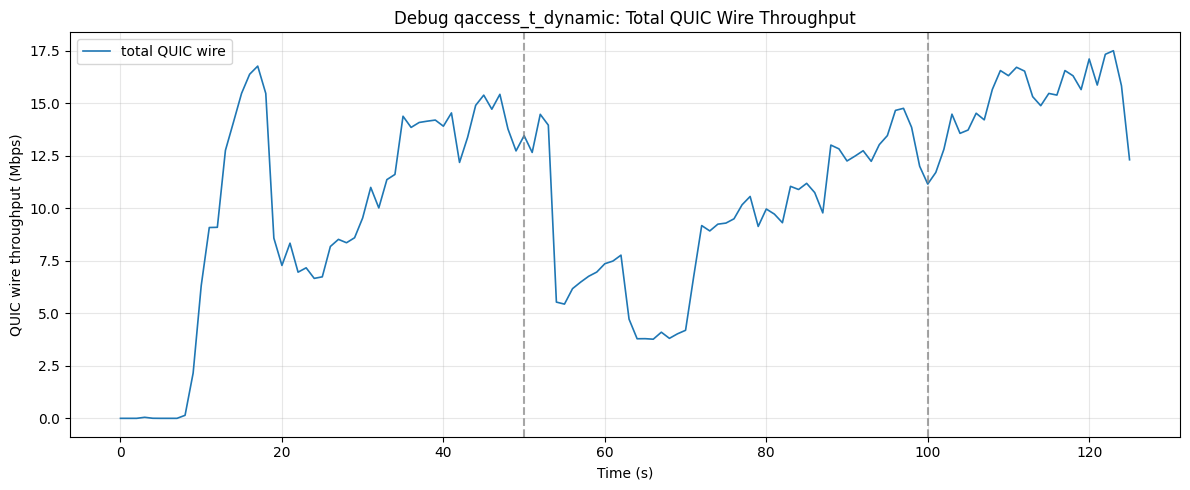

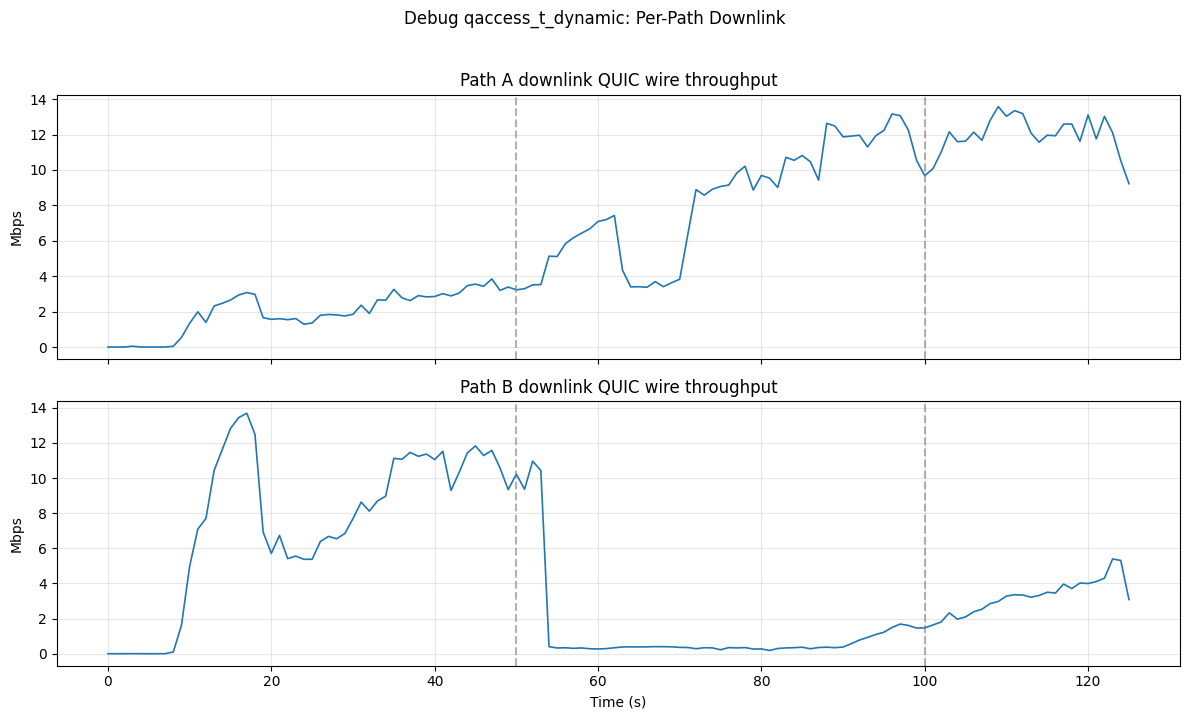

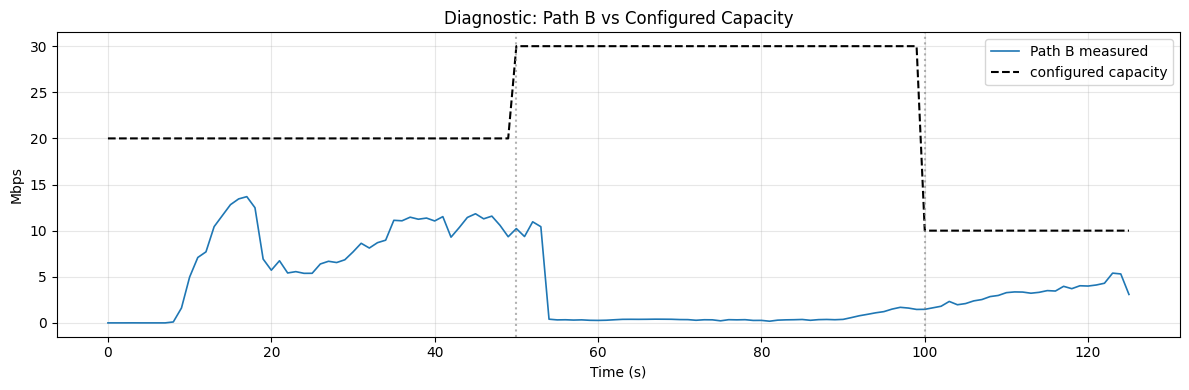

Saved figures to /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic/compare_csv


In [7]:
def configured_path_b_capacity(second: int) -> float:
    if second < 50:
        return 20.0
    if second < 100:
        return 30.0
    return 10.0

cap = [configured_path_b_capacity(int(s)) for s in df["second"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["second"], df["total_quic_mbps"], label="total QUIC wire", linewidth=1.2)
for t in (50, 100):
    ax.axvline(t, linestyle="--", color="gray", alpha=0.7)
ax.set(xlabel="Time (s)", ylabel="QUIC wire throughput (Mbps)",
       title="Debug qaccess_t_dynamic: Total QUIC Wire Throughput")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_TOTAL, dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, title in [(axes[0], "pathA_quic_mbps", "Path A downlink"), (axes[1], "pathB_quic_mbps", "Path B downlink")]:
    ax.plot(df["second"], df[col], linewidth=1.2)
    for t in (50, 100):
        ax.axvline(t, linestyle="--", color="gray", alpha=0.6)
    ax.set_ylabel("Mbps")
    ax.set_title(title + " QUIC wire throughput")
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel("Time (s)")
fig.suptitle("Debug qaccess_t_dynamic: Per-Path Downlink", y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATHS, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["second"], df["pathB_quic_mbps"], label="Path B measured", linewidth=1.2)
ax.plot(df["second"], cap, label="configured capacity", linestyle="--", color="black")
for t in (50, 100):
    ax.axvline(t, linestyle=":", color="gray", alpha=0.6)
ax.set(xlabel="Time (s)", ylabel="Mbps", title="Diagnostic: Path B vs Configured Capacity")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_PATHB_CAP, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figures to", OUT_DIR)


## 8. Compare: fig7_baseline (last session) vs debug qaccess_t_dynamic

Same Fig.7 topology / TBF profile; different runs:
- **fig7_baseline** — `session_fig7_dynamic_20260601_101430` (utility-mode baseline)
- **debug qaccess_t_dynamic** — this session (utility-mode qaccess_t with Phase 2 env)

Metric: QUIC wire downlink (Path A + Path B). Run §5 first so `read_bins` / `df` exist.


In [10]:
def load_run_timeseries(run_path: Path, label: str):
    pcaps_dir = run_path / "pcaps"
    pa = next(pcaps_dir.glob("pathA*.pcap"), None)
    pb = next(pcaps_dir.glob("pathB*.pcap"), None)
    if not pa or not pb:
        print(f"[{label}] missing pcaps under {pcaps_dir}")
        return None
    print(f"Loading [{label}] ...", flush=True)
    ba = read_bins(pa, PATH_A_DOWNLINK)
    bb = read_bins(pb, PATH_B_DOWNLINK)
    ls = int(min(SECOND_MAX, max(ba.keys(), default=0), max(bb.keys(), default=0)))
    out = to_df(ba, bb, ls)
    out["run"] = label
    return out


df_baseline = load_run_timeseries(BASELINE_RUN, "fig7_baseline")
df_debug = df.copy()
df_debug["run"] = "debug_qaccess_t_dynamic"

FIG_COMPARE_TOTAL = OUT_DIR / "compare_baseline_vs_debug_total.png"
FIG_COMPARE_PATHS = OUT_DIR / "compare_baseline_vs_debug_per_path.png"
CSV_COMPARE_WINDOWS = OUT_DIR / "compare_baseline_vs_debug_windows.csv"

if df_baseline is not None:
    # --- total over time ---
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_baseline["second"], df_baseline["total_quic_mbps"],
            label="fig7_baseline (last session)", linewidth=1.2)
    ax.plot(df_debug["second"], df_debug["total_quic_mbps"],
            label="debug qaccess_t_dynamic", linewidth=1.2)
    for t in (50, 100):
        ax.axvline(t, linestyle="--", color="gray", alpha=0.6)
    ax.set(xlabel="Time from pcap start (s)", ylabel="QUIC wire throughput (Mbps)",
           title="Fig.7 baseline vs debug qaccess_t_dynamic: Total QUIC Wire Throughput")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_COMPARE_TOTAL, dpi=200, bbox_inches="tight")
    plt.show()

    # --- per path ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    for ax, col, title in [
        (axes[0], "pathA_quic_mbps", "Path A downlink"),
        (axes[1], "pathB_quic_mbps", "Path B downlink"),
    ]:
        ax.plot(df_baseline["second"], df_baseline[col], label="fig7_baseline", linewidth=1.0)
        ax.plot(df_debug["second"], df_debug[col], label="debug qaccess_t_dynamic", linewidth=1.0)
        for t in (50, 100):
            ax.axvline(t, linestyle="--", color="gray", alpha=0.5)
        ax.set_ylabel("Mbps")
        ax.set_title(title + " QUIC wire throughput")
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[1].set_xlabel("Time from pcap start (s)")
    fig.suptitle("Fig.7 baseline vs debug qaccess_t_dynamic", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_COMPARE_PATHS, dpi=200, bbox_inches="tight")
    plt.show()

    # --- window table ---
    def mean_run(dfr, col, lo, hi):
        w = dfr[(dfr["second"] >= lo) & (dfr["second"] < hi)]
        return float(w[col].mean()) if len(w) else float("nan")

    cmp_rows = []
    for wname, lo, hi in WINDOWS + [("full", 0, max(df_baseline["second"].max(), df_debug["second"].max()) + 1)]:
        b = mean_run(df_baseline, "total_quic_mbps", lo, hi)
        d = mean_run(df_debug, "total_quic_mbps", lo, hi)
        imp = (d - b) / b * 100 if b > 0 else float("nan")
        cmp_rows.append({
            "window": wname,
            "baseline_total_mbps": round(b, 3),
            "debug_qaccess_t_total_mbps": round(d, 3),
            "debug_vs_baseline_pct": round(imp, 2),
            "baseline_pathB_mbps": round(mean_run(df_baseline, "pathB_quic_mbps", lo, hi), 3),
            "debug_pathB_mbps": round(mean_run(df_debug, "pathB_quic_mbps", lo, hi), 3),
        })
    df_cmp = pd.DataFrame(cmp_rows)
    df_cmp.to_csv(CSV_COMPARE_WINDOWS, index=False)
    print("Wrote", CSV_COMPARE_WINDOWS)
    display(df_cmp)
    print("Saved", FIG_COMPARE_TOTAL, FIG_COMPARE_PATHS)
else:
    print("Skip comparison: sync fig7_baseline pcaps to", BASELINE_RUN)


NameError: name 'BASELINE_RUN' is not defined

## 9. Optional: compare with failed fig7_dynamic leg (pcap)

Loading failed-run pcaps...


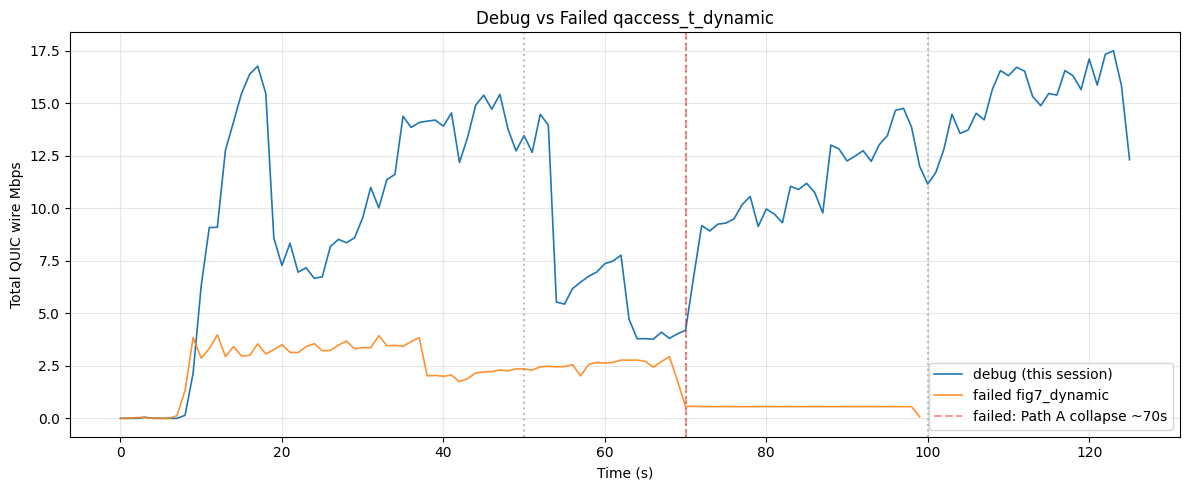


Mean total Mbps by window:
  0-50: debug=9.36 failed=2.50
  50-100: debug=9.39 failed=1.33
  100-end: debug=15.13 failed=nan


In [8]:
def load_failed_ts() -> pd.DataFrame | None:
    pa_f = list((FAILED_RUN / "pcaps").glob("pathA*.pcap")) if FAILED_RUN.is_dir() else []
    pb_f = list((FAILED_RUN / "pcaps").glob("pathB*.pcap")) if FAILED_RUN.is_dir() else []
    if not pa_f or not pb_f:
        print("Failed-run pcaps not found — skip overlay")
        return None
    print("Loading failed-run pcaps...", flush=True)
    ba_f = read_bins(pa_f[0], PATH_A_DOWNLINK)
    bb_f = read_bins(pb_f[0], PATH_B_DOWNLINK)
    ls = int(min(max(ba_f.keys(), default=0), max(bb_f.keys(), default=0)))
    dff = to_df(ba_f, bb_f, ls)
    dff["run"] = "failed_fig7_dynamic"
    return dff

df_fail = load_failed_ts()
if df_fail is not None:
    dfc = df.copy()
    dfc["run"] = "debug_ok"
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dfc["second"], dfc["total_quic_mbps"], label="debug (this session)", linewidth=1.2)
    ax.plot(df_fail["second"], df_fail["total_quic_mbps"], label="failed fig7_dynamic", linewidth=1.2, alpha=0.85)
    for t in (50, 70, 100):
        ax.axvline(t, linestyle=":", color="gray", alpha=0.5)
    ax.axvline(70, linestyle="--", color="red", alpha=0.4, label="failed: Path A collapse ~70s")
    ax.set(xlabel="Time (s)", ylabel="Total QUIC wire Mbps",
           title="Debug vs Failed qaccess_t_dynamic")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    print("\nMean total Mbps by window:")
    for name, lo, hi in [("0-50",0,50),("50-100",50,100),("100-end",100,9999)]:
        m_ok = mean_win("total_quic_mbps", lo, min(hi, last_s+1))
        w = df_fail[(df_fail["second"]>=lo)&(df_fail["second"]<hi)]
        m_f = float(w["total_quic_mbps"].mean()) if len(w) else float("nan")
        print(f"  {name}: debug={m_ok:.2f} failed={m_f:.2f}")


## 10. Summary

In [9]:
print("=" * 60)
print("Debug session summary")
print("=" * 60)
print("Session:", SESSION.resolve())
print("Pcap duration (s):", last_s + 1)
print("Mean total QUIC wire (full):", round(float(df["total_quic_mbps"].mean()), 3), "Mbps")
if OUTPUT_FLV.is_file():
    print("Output FLV est app Mbps:", round(flv_size_mbps(OUTPUT_FLV, last_s + 1), 3))
print("Triggers:", len(triggers), "| Reloads:", len(reloads))
print("Stall watchdog in logs:", "yes" if any("stalled" in x for x in wd) else "no")
print("\nOutputs:", OUT_DIR.resolve())


Debug session summary
Session: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic
Pcap duration (s): 126
Mean total QUIC wire (full): 10.563 Mbps
Output FLV est app Mbps: 9.65
Triggers: 1 | Reloads: 5
Stall watchdog in logs: no

Outputs: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_debug_qaccess_t_dynamic/compare_csv
